In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Debería hacer lo mismo para los 4 datasets (50k, 1M, etc), quizá usar 8M de imágenes sea demasiado para mi PC. Este proyecto puede ser como el de wikimedia de la tarea pero con texto e imágenes

In [2]:
interaction50k = pd.read_csv("Datos/Pixel50k/interaction.csv")
item_info50k = pd.read_csv("Datos/Pixel50k/item_info.csv")

In [10]:
# Procesamiento y limpieza de datos
interaction50k['timestamp_not_unix'] = pd.to_datetime(interaction50k['timestamp'].astype(int), unit='s')

In [39]:
# Generar distribución timestamp para interacciones
def dist_timestamp(interacciones: pd.DataFrame):
    # plt.figure(figsize=(8, 4), dpi=300)
    plt.hist(interacciones['timestamp_not_unix'], bins=50, color='lightblue', edgecolor='black')
    plt.title("Distribución timestamp")
    plt.xlabel("Tiempo")
    plt.ylabel("Frecuencia")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.savefig('dist-timestamp_train.jpeg')
    plt.show()

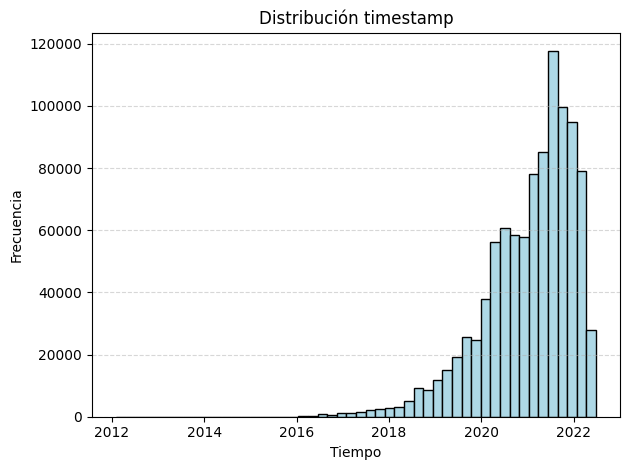

In [40]:
dist_timestamp(interaction50k)

Si hay valores antes de 2016, pero muy poco. Comprobar si es lo mismo en todos los datasets

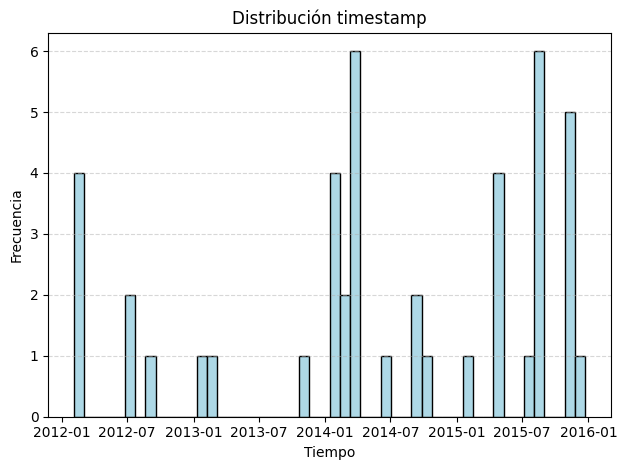

In [41]:
antes2016 = interaction50k[ interaction50k['timestamp_not_unix'].dt.year < 2016 ]
dist_timestamp(antes2016)

In [27]:
# Calcular cantidad y densidad de interacciones, no sé que más agregarle
def stats_interacciones(interacciones: pd.DataFrame):
    cant_users = len(interacciones["user_id"].unique())
    cant_items = len(interacciones["item_id"].unique())
    total_interacciones = len(interacciones) 
    densidad = (total_interacciones / (cant_users * cant_items)) * 100
    print(f"Cant. de usuarios en df: {cant_users}\nCant de items en df: {cant_items}\nDensidad del df: {densidad}%")
    return cant_users, cant_items, densidad

In [28]:
stats_interacciones(interaction50k)

Cant. de usuarios en df: 50000
Cant de items en df: 82865
Densidad del df: 0.02388207325167441%


(50000, 82865, 0.02388207325167441)

Cantidad de usuarios con una cantidad de interacciones

In [ ]:
def interacciones_por_usuario(interacciones):
    interacciones_por_usuario = interacciones.groupby('user_id').size()
    distribucion = interacciones_por_usuario.value_counts().sort_index()
    plt.figure()
    plt.plot(distribucion.index, distribucion.values)
    plt.xscale('log')
    # plt.yscale('log')
    plt.xlabel("Cantidad de interacciones")
    plt.ylabel("Cantidad de usuarios")
    plt.title("Distribución de interacciones por usuario")

    plt.show()

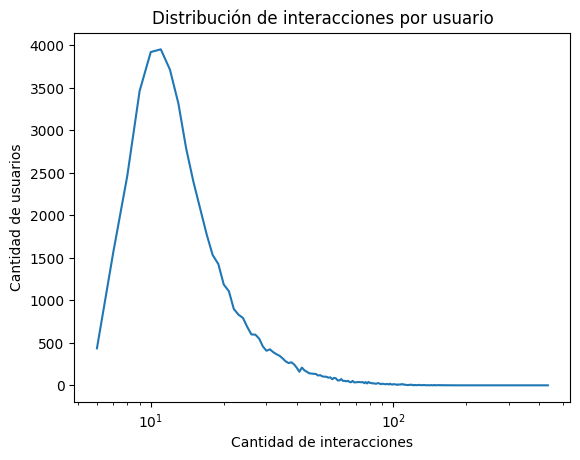

In [38]:
interacciones_por_usuario(interaction50k)

Ahora faltaría una descripción de item_info, sobre las imágenes no sé si se pueda decir mucho más que su cantidad

In [44]:
item_info50k.head(2)

,item_id,view_number,comment_number,thumbup_number,share_number,coin_number,favorite_number,barrage_number,title,tag,description
0,i192714,799668.0,739.0,8050.0,220.0,84.0,1049.0,510.0,"My boyfriend gave me a turtle, and it suddenly...",Pet Reptiles,Should I brush it off?
1,i225967,1201395.0,102.0,20424.0,738.0,502.0,4307.0,510.0,Who's not a baby anymore! Alaska is being bull...,Dogs,BGM: Don't Leave Me (Ne Me Quitte Pas) - Regin...


In [43]:
len(item_info50k["tag"].unique())

109

In [58]:
# Un gráfico por view_number sería lo más normal
def graph_dist(item_info, col_name, xscale="linear", yscale="linear"):
    # plt.figure(figsize=(10, 5), dpi=300)
    plt.hist(item_info[col_name], bins=50, color='lightblue', edgecolor='black')

    plt.title(f"Distribución {col_name}")
    plt.xlabel("item_id")
    plt.xscale(xscale)
    plt.yscale(yscale)
    plt.ylabel("Frecuencia")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.savefig('')
    plt.show()

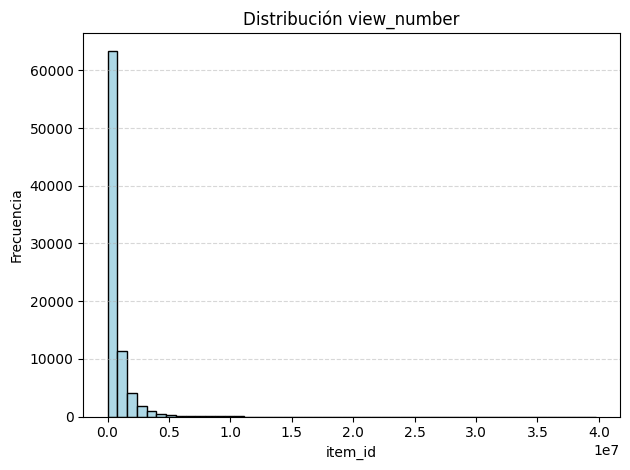

In [59]:
graph_dist(item_info50k, "view_number")

La gran mayoría de los items ha sido compartida un número muy pequeño de veces, no sé si most-popular sirva

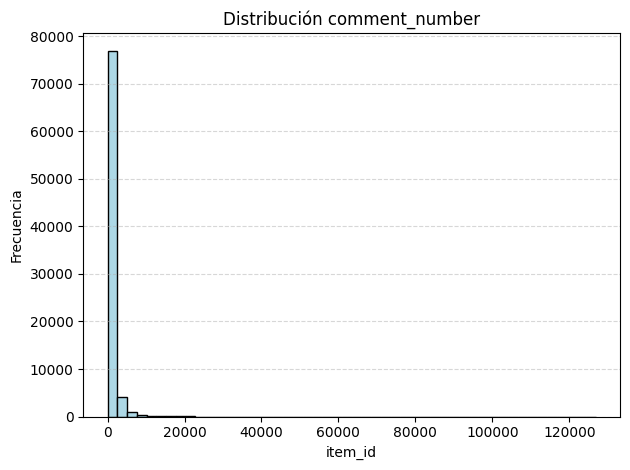

In [60]:
graph_dist(item_info50k, "comment_number")

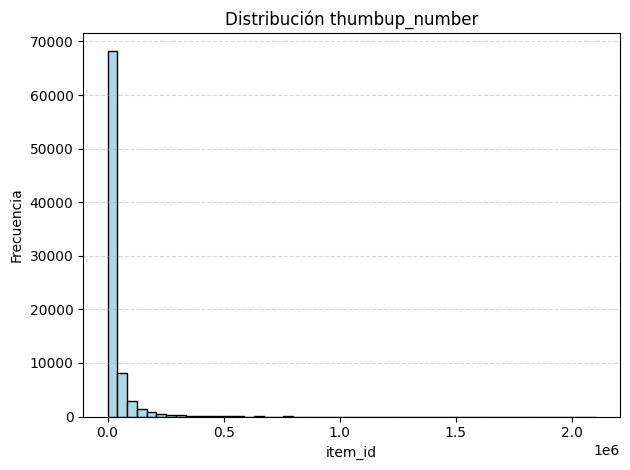

In [62]:
graph_dist(item_info50k, "thumbup_number")

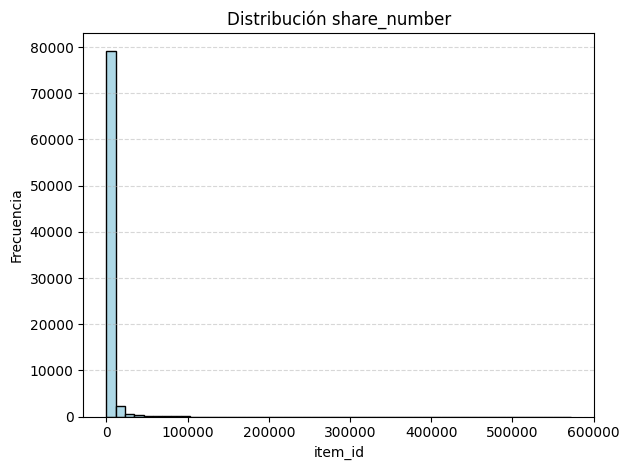

In [63]:
graph_dist(item_info50k, "share_number")

categorías más populares

In [82]:
def cat_most_popular(item_info: pd.DataFrame):
    por_cat = item_info.groupby("tag")["view_number"].sum().sort_values(ascending=False)
    plt.figure(figsize=(12, 5), dpi=300)
    plt.plot(por_cat, color='lightblue')

    plt.title(f"Vistas por categoría")
    plt.xlabel("categoría")
    plt.xticks(rotation=45)
    #plt.xscale(xscale)
    #plt.yscale(yscale)
    plt.ylabel("Vistas")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.savefig('')
    plt.show()


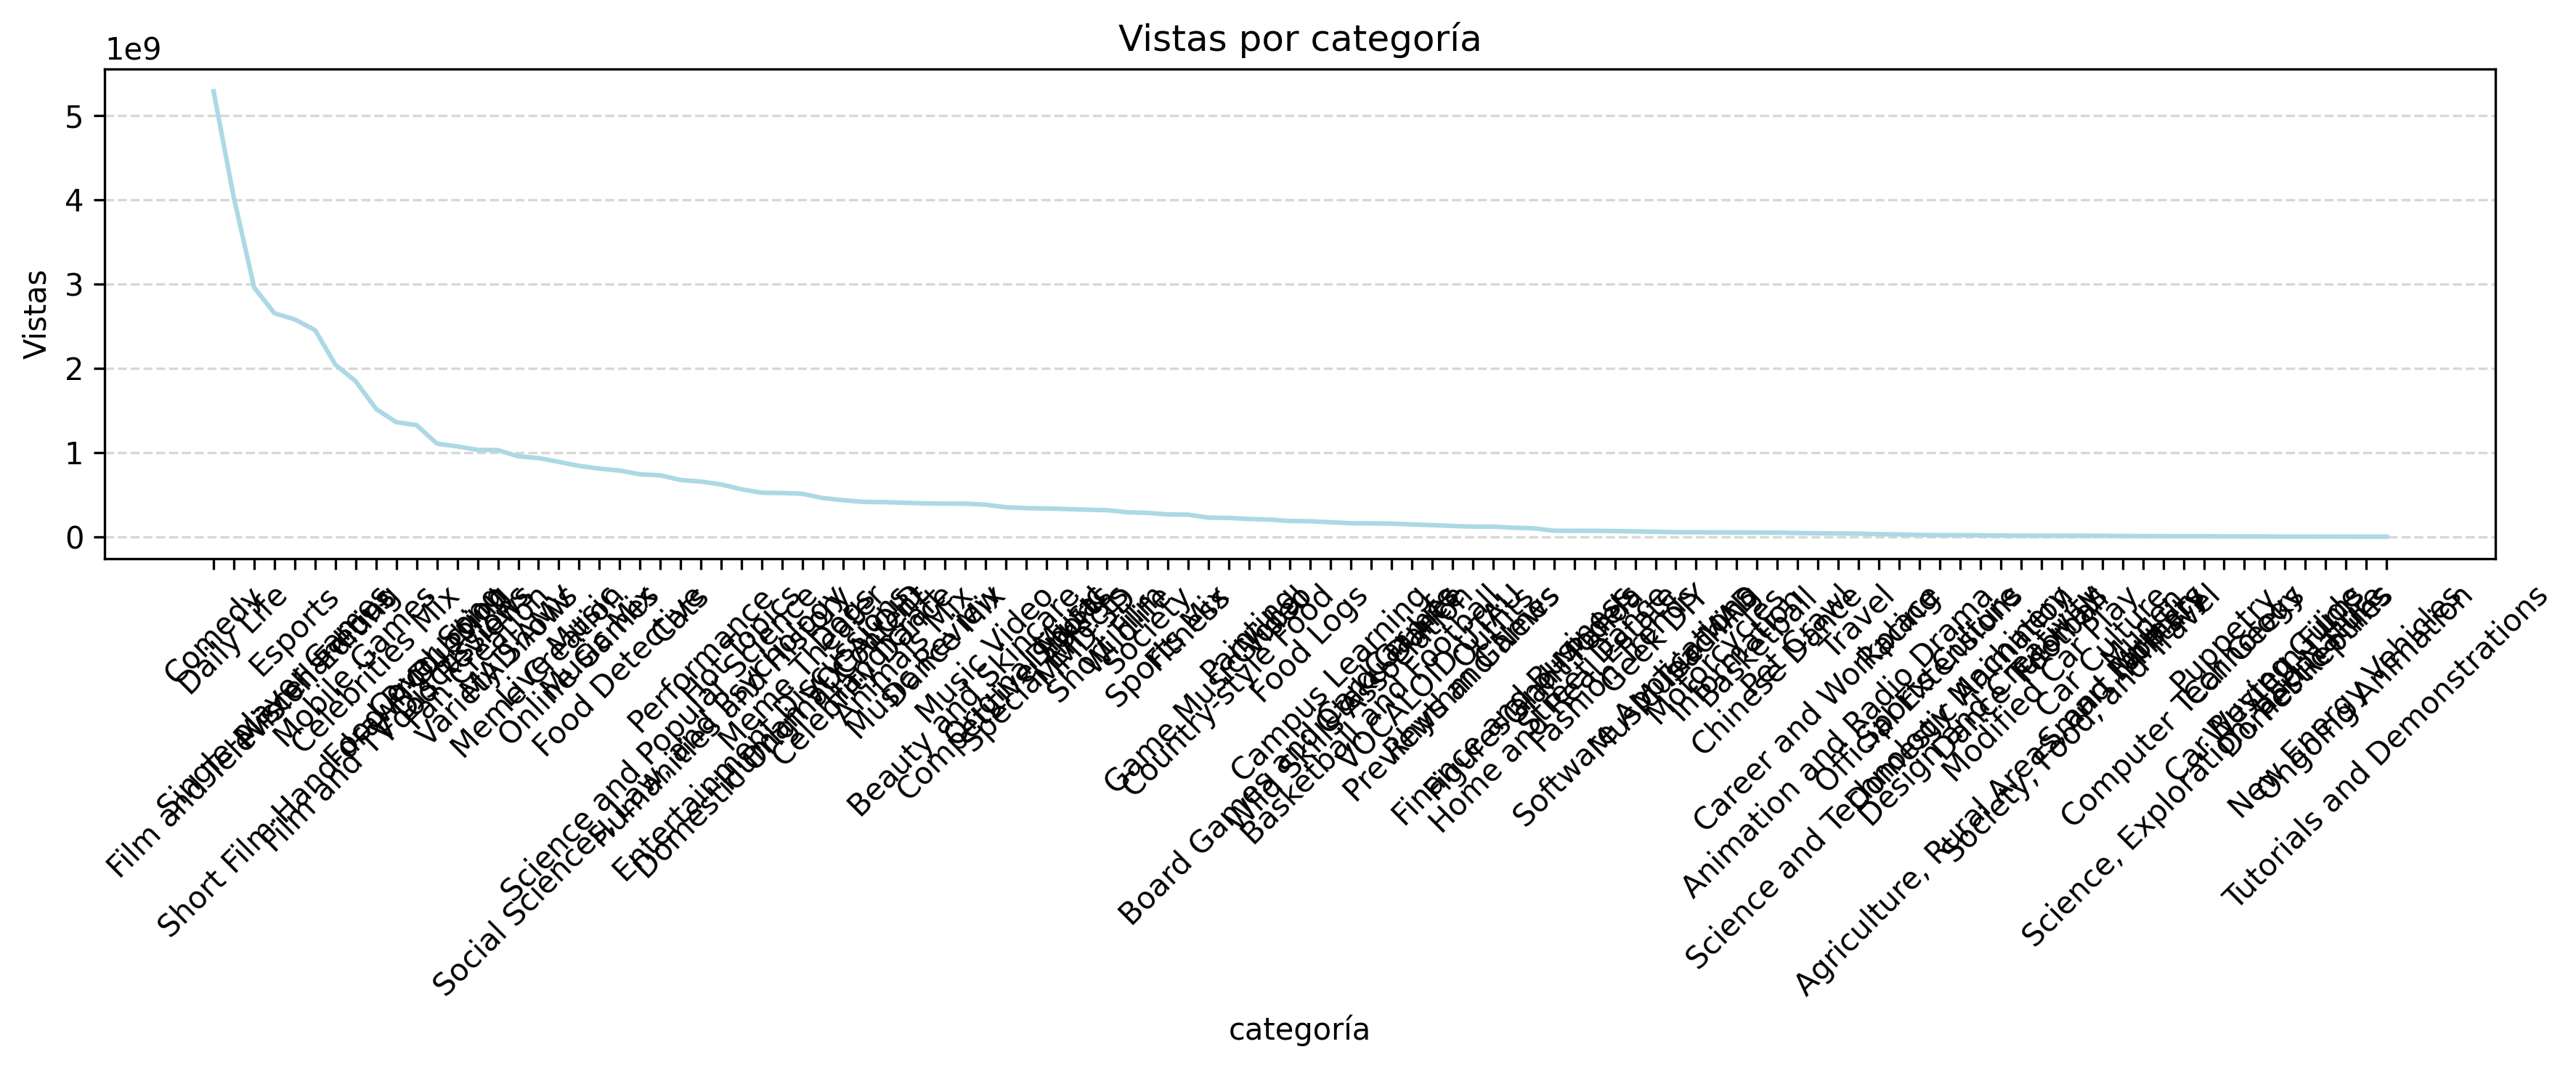

In [83]:
cat_most_popular(item_info50k)